## Setup (igual que antes)

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

load_dotenv()
url = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME_ORIGEN')}"
)
engine = create_engine(url)

def q(sql: str) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

OUT_DIR = Path("../docs/eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Setup OK ✓")

Setup OK ✓


##  Rango temporal de las ventas (clave para "vida útil del cliente")

In [2]:
rango = q("""
    SELECT 
        MIN(sale_date)::date AS primera_venta,
        MAX(sale_date)::date AS ultima_venta,
        MAX(sale_date)::date - MIN(sale_date)::date AS dias_cubiertos,
        COUNT(DISTINCT DATE(sale_date)) AS dias_con_ventas,
        COUNT(*) AS total_ventas
    FROM sale;
""")
rango

,primera_venta,ultima_venta,dias_cubiertos,dias_con_ventas,total_ventas
0,2020-01-01,2025-12-30,2190,2187,20000


In [3]:
# Ventas por mes — ¿hay estacionalidad? ¿el dataset es completo en todos los meses?
ventas_mes = q("""
    SELECT 
        DATE_TRUNC('month', sale_date)::date AS mes,
        COUNT(*) AS num_ventas,
        SUM(total) AS ingresos_totales,
        ROUND(AVG(total)::numeric, 2) AS ticket_medio
    FROM sale
    GROUP BY mes
    ORDER BY mes;
""")
print(f"Meses con ventas: {len(ventas_mes)}")
ventas_mes

Meses con ventas: 72


,mes,num_ventas,ingresos_totales,ticket_medio
0,2020-01-01,223,132114.93,592.44
1,2020-02-01,177,114214.89,645.28
2,2020-03-01,231,129060.63,558.70
3,2020-04-01,220,127109.40,577.77
4,2020-05-01,191,112917.96,591.19
...,...,...,...,...
67,2025-08-01,203,108588.72,534.92
68,2025-09-01,685,200048.32,292.04
69,2025-10-01,694,198405.68,285.89
70,2025-11-01,457,163162.71,357.03


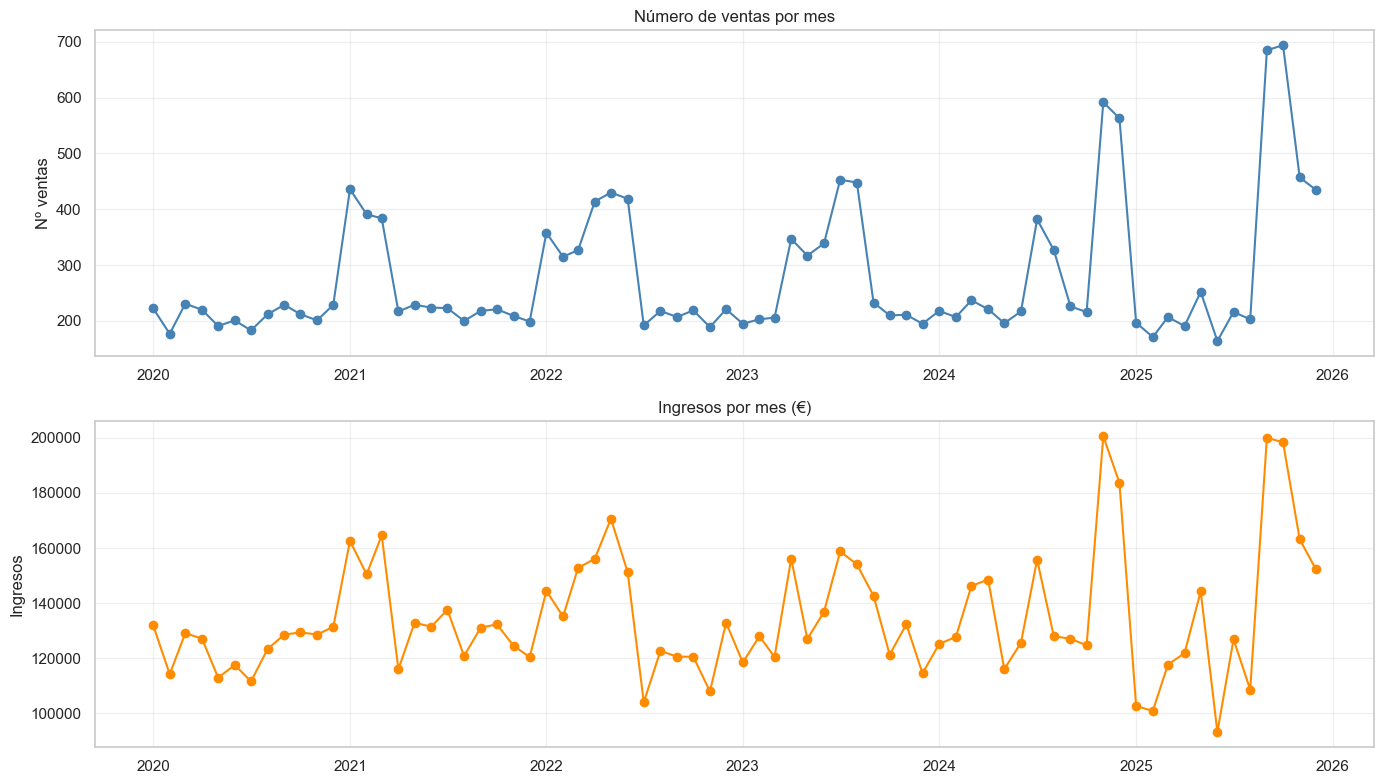

In [4]:
# Visualización
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
ax[0].plot(ventas_mes['mes'], ventas_mes['num_ventas'], marker='o', color='steelblue')
ax[0].set_title('Número de ventas por mes')
ax[0].set_ylabel('Nº ventas')
ax[0].grid(True, alpha=0.3)

ax[1].plot(ventas_mes['mes'], ventas_mes['ingresos_totales'], marker='o', color='darkorange')
ax[1].set_title('Ingresos por mes (€)')
ax[1].set_ylabel('Ingresos')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_ventas_por_mes.png", dpi=120, bbox_inches='tight')
plt.show()

## Comportamiento de compra por cliente (esencial para CLTV)

In [5]:
# ¿Cuántas compras hace cada cliente?
compras_cliente = q("""
    SELECT 
        c.customer_id,
        COUNT(s.sale_id) AS num_compras,
        ROUND(SUM(s.total)::numeric, 2) AS ingresos_totales,
        ROUND(AVG(s.total)::numeric, 2) AS ticket_medio,
        MIN(s.sale_date)::date AS primera_compra,
        MAX(s.sale_date)::date AS ultima_compra,
        (MAX(s.sale_date)::date - MIN(s.sale_date)::date) AS dias_relacion
    FROM customer c
    LEFT JOIN sale s ON c.customer_id = s.customer_id
    GROUP BY c.customer_id;
""")
print(f"Total clientes: {len(compras_cliente)}")
print(f"\nDistribución del nº de compras por cliente:")
print(compras_cliente['num_compras'].describe())
print(f"\nClientes que NO han comprado nunca: {(compras_cliente['num_compras']==0).sum()}")
print(f"Clientes con UNA sola compra (one-shot): {(compras_cliente['num_compras']==1).sum()}")
print(f"Clientes recurrentes (≥2 compras): {(compras_cliente['num_compras']>=2).sum()}")

Total clientes: 5750

Distribución del nº de compras por cliente:
count    5750.000000
mean        3.478261
std         6.585678
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        34.000000
Name: num_compras, dtype: float64

Clientes que NO han comprado nunca: 0
Clientes con UNA sola compra (one-shot): 5000
Clientes recurrentes (≥2 compras): 750


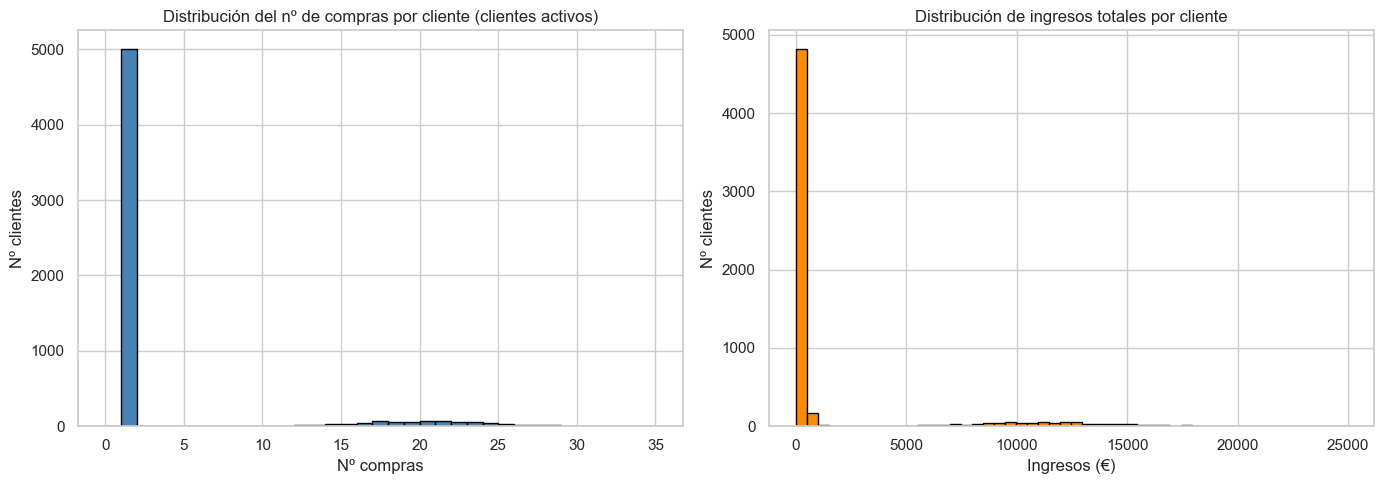

In [6]:
# Histograma de nº compras por cliente (excluyendo los que no compraron)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

activos = compras_cliente[compras_cliente['num_compras']>0]
ax[0].hist(activos['num_compras'], bins=range(0, int(activos['num_compras'].max())+2), 
           edgecolor='black', color='steelblue')
ax[0].set_title('Distribución del nº de compras por cliente (clientes activos)')
ax[0].set_xlabel('Nº compras')
ax[0].set_ylabel('Nº clientes')

ax[1].hist(activos['ingresos_totales'], bins=50, edgecolor='black', color='darkorange')
ax[1].set_title('Distribución de ingresos totales por cliente')
ax[1].set_xlabel('Ingresos (€)')
ax[1].set_ylabel('Nº clientes')

plt.tight_layout()
plt.savefig(FIG_DIR / "02_distribucion_clientes.png", dpi=120, bbox_inches='tight')
plt.show()

## Pareto: ¿concentración del negocio en pocos clientes

El top 20% de clientes genera el 93.7% de los ingresos


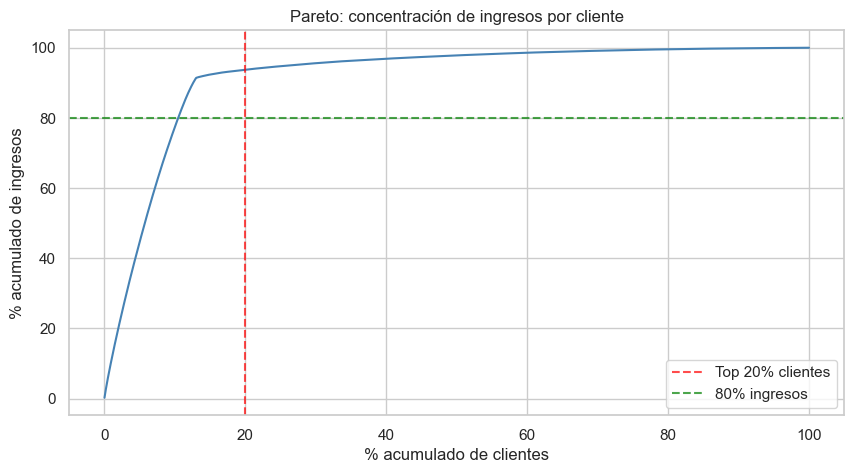

In [7]:
activos_sorted = activos.sort_values('ingresos_totales', ascending=False).reset_index(drop=True)
activos_sorted['acum_ingresos'] = activos_sorted['ingresos_totales'].cumsum()
total_ingresos = activos_sorted['ingresos_totales'].sum()
activos_sorted['pct_acum'] = activos_sorted['acum_ingresos'] / total_ingresos * 100
activos_sorted['pct_cliente'] = (activos_sorted.index + 1) / len(activos_sorted) * 100

# Top 20% de clientes generan qué % de ingresos
top20_cliente_pct = activos_sorted.iloc[int(len(activos_sorted)*0.2)]['pct_acum']
print(f"El top 20% de clientes genera el {top20_cliente_pct:.1f}% de los ingresos")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(activos_sorted['pct_cliente'], activos_sorted['pct_acum'], color='steelblue')
ax.axvline(20, color='red', linestyle='--', alpha=0.7, label='Top 20% clientes')
ax.axhline(80, color='green', linestyle='--', alpha=0.7, label='80% ingresos')
ax.set_xlabel('% acumulado de clientes')
ax.set_ylabel('% acumulado de ingresos')
ax.set_title('Pareto: concentración de ingresos por cliente')
ax.legend()
plt.savefig(FIG_DIR / "03_pareto_clientes.png", dpi=120, bbox_inches='tight')
plt.show()

## Patrones temporales (día de la semana, hora del día)

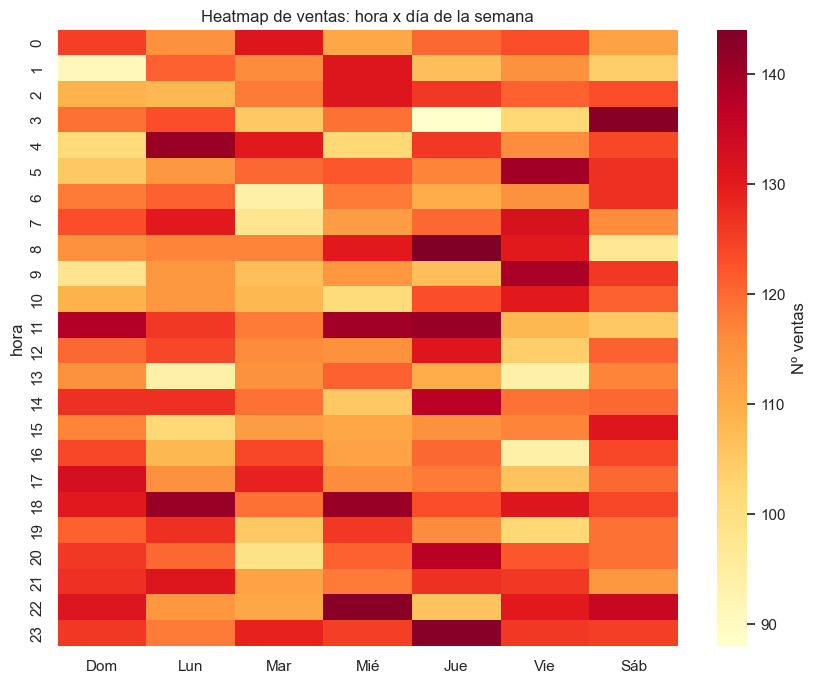

In [8]:
patrones = q("""
    SELECT 
        EXTRACT(DOW FROM sale_date)::int AS dia_semana,  -- 0=domingo
        EXTRACT(HOUR FROM sale_date)::int AS hora,
        COUNT(*) AS num_ventas,
        SUM(total) AS ingresos
    FROM sale
    GROUP BY dia_semana, hora
    ORDER BY dia_semana, hora;
""")

# Heatmap día x hora
pivot = patrones.pivot(index='hora', columns='dia_semana', values='num_ventas').fillna(0)
dias = ['Dom','Lun','Mar','Mié','Jue','Vie','Sáb']
pivot.columns = [dias[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, ax=ax, cbar_kws={'label':'Nº ventas'})
ax.set_title('Heatmap de ventas: hora x día de la semana')
plt.savefig(FIG_DIR / "04_heatmap_temporal.png", dpi=120, bbox_inches='tight')
plt.show()

## Análisis de devoluciones

In [9]:
# % de devoluciones sobre ventas
returns_stats = q("""
    SELECT 
        COUNT(DISTINCT ri.return_id) AS num_devoluciones,
        COUNT(DISTINCT ri.sale_item_id) AS items_devueltos,
        (SELECT COUNT(*) FROM sale_item) AS total_items,
        ROUND(100.0 * COUNT(DISTINCT ri.sale_item_id) / (SELECT COUNT(*) FROM sale_item), 2) AS pct_items_devueltos,
        SUM(ri.quantity) AS unidades_devueltas
    FROM return_item ri;
""")
returns_stats

,num_devoluciones,items_devueltos,total_items,pct_items_devueltos,unidades_devueltas
0,2330,2264,42555,5.32,2330


In [10]:
# Devoluciones por cliente
returns_cliente = q("""
    SELECT 
        s.customer_id,
        COUNT(DISTINCT ri.return_id) AS num_devoluciones,
        SUM(ri.quantity) AS unidades_devueltas
    FROM return_item ri
    JOIN sale_item si ON ri.sale_item_id = si.sale_item_id
    JOIN sale s ON si.sale_id = s.sale_id
    GROUP BY s.customer_id
    ORDER BY num_devoluciones DESC;
""")
print(f"Clientes con al menos una devolución: {len(returns_cliente)} de 5750 ({100*len(returns_cliente)/5750:.1f}%)")
print(f"Top 10 clientes por nº devoluciones:")
returns_cliente.head(10)

Clientes con al menos una devolución: 1124 de 5750 (19.5%)
Top 10 clientes por nº devoluciones:


,customer_id,num_devoluciones,unidades_devueltas
0,499,8,8
1,342,8,8
2,529,7,7
3,665,7,7
4,671,7,7
5,88,7,7
6,168,7,7
7,564,7,7
8,661,7,7
9,198,6,6


## Productos más vendidos y categorías

In [11]:
top_productos = q("""
    SELECT 
        p.product_id,
        p.name,
        p.category,
        SUM(si.quantity) AS unidades_vendidas,
        ROUND(SUM(si.subtotal)::numeric, 2) AS ingresos,
        COUNT(DISTINCT si.sale_id) AS num_ventas_aparece
    FROM sale_item si
    JOIN product p ON si.product_id = p.product_id
    GROUP BY p.product_id, p.name, p.category
    ORDER BY ingresos DESC;
""")
print("Top 15 productos por ingresos:")
top_productos.head(15)

Top 15 productos por ingresos:


,product_id,name,category,unidades_vendidas,ingresos,num_ventas_aparece
0,45,Scanner venoso portátil,Diagnóstico,1586,634384.14,824
1,33,Purificador HEPA Pro,Wellness,1732,606182.68,890
2,17,Silla de ruedas plegable,Movilidad,1626,487783.74,820
3,43,Colchón ortopédico premium,Rehabilitación,1604,481183.96,848
4,31,Báscula profesional médica,Diagnóstico,1775,443732.25,903
5,41,Kit de oxigenoterapia,Tratamiento,1560,389984.40,767
6,14,Colchón antiescaras,Rehabilitación,1672,334232.80,857
7,38,Análisis corporal avanzado,Wellness,1639,311393.61,833
8,34,Silla ortopédica ajustable,Movilidad,1520,303984.80,804
9,46,Detector apnea portátil,Diagnóstico,1605,288883.95,826


In [12]:
# Por categoría
cat = q("""
    SELECT 
        p.category,
        COUNT(DISTINCT p.product_id) AS num_productos,
        SUM(si.quantity) AS unidades,
        ROUND(SUM(si.subtotal)::numeric, 2) AS ingresos
    FROM sale_item si
    JOIN product p ON si.product_id = p.product_id
    GROUP BY p.category
    ORDER BY ingresos DESC;
""")
cat

,category,num_productos,unidades,ingresos
0,Diagnóstico,14,22971,2830098.95
1,Wellness,14,23049,2816902.70
2,Rehabilitación,7,11596,1598260.28
3,Movilidad,5,8193,1175394.23
4,Tratamiento,5,7725,876914.47
5,Higiene,4,6831,352602.30
6,Domótica Salud,1,1426,28505.74


## Margen estimado a nivel global

In [13]:
# Margen total del negocio (excluyendo el producto huérfano 29)
margen = q("""
    SELECT 
        COUNT(*) AS items,
        ROUND(SUM(si.subtotal)::numeric, 2) AS ingresos_totales,
        ROUND(SUM(si.quantity * cp.unit_cost)::numeric, 2) AS coste_total,
        ROUND((SUM(si.subtotal) - SUM(si.quantity * cp.unit_cost))::numeric, 2) AS margen_bruto,
        ROUND((100.0 * (SUM(si.subtotal) - SUM(si.quantity * cp.unit_cost)) / SUM(si.subtotal))::numeric, 2) AS pct_margen
    FROM sale_item si
    JOIN central_product cp ON si.product_id = cp.product_id;  -- no incluye el producto 29
""")
margen

,items,ingresos_totales,coste_total,margen_bruto,pct_margen
0,41844,9650172.93,5789901.65,3860271.28,40.0


In [14]:
# Margen por categoría
margen_cat = q("""
    SELECT 
        p.category,
        ROUND(SUM(si.subtotal)::numeric, 2) AS ingresos,
        ROUND(SUM(si.quantity * cp.unit_cost)::numeric, 2) AS coste,
        ROUND((SUM(si.subtotal) - SUM(si.quantity * cp.unit_cost))::numeric, 2) AS margen,
        ROUND((100.0 * (SUM(si.subtotal) - SUM(si.quantity * cp.unit_cost)) / SUM(si.subtotal))::numeric, 2) AS pct_margen
    FROM sale_item si
    JOIN product p ON si.product_id = p.product_id
    JOIN central_product cp ON si.product_id = cp.product_id
    GROUP BY p.category
    ORDER BY margen DESC;
""")
margen_cat

,category,ingresos,coste,margen,pct_margen
0,Diagnóstico,2830098.95,1697991.09,1132107.86,40.0
1,Wellness,2816902.70,1690087.16,1126815.54,40.0
2,Rehabilitación,1598260.28,958922.84,639337.44,40.0
3,Movilidad,1175394.23,705217.27,470176.96,40.0
4,Tratamiento,876914.47,526136.15,350778.32,40.0
5,Higiene,352602.30,211547.14,141055.16,40.0


## Calidad: la venta anómala 13009

In [15]:
# Investigar la única venta incoherente
anomala = q("""
    SELECT s.sale_id, s.sale_date, s.total AS total_sale,
           si.sale_item_id, si.product_id, si.quantity, 
           si.unit_price, si.offer_id, si.subtotal
    FROM sale s
    JOIN sale_item si ON s.sale_id = si.sale_id
    WHERE s.sale_id = 13009;
""")
print("Detalle de la venta anómala 13009:")
anomala

Detalle de la venta anómala 13009:


,sale_id,sale_date,total_sale,sale_item_id,product_id,quantity,unit_price,offer_id,subtotal
0,13009,2024-05-02 07:04:41.972130,324.77,32542,4,3,34.99,NaN,104.97
1,13009,2024-05-02 07:04:41.972130,324.77,32543,2,1,29.99,1.0,26.99
2,13009,2024-05-02 07:04:41.972130,324.77,32544,30,2,99.90,1.0,189.81
